# Оценка стоимости  и типа трансмиссии по данным продаж автомобилей на вторичном рынке Молдавии

задача является реальной задачей, предложенной в качестве одного из соревнований на платформе kaggle.com

https://www.kaggle.com/alexandrududa/cars-moldova

Набор данных представляет собой статистику параметров автомобилей на вторичном рынке в Молдавии. Набор включает ряд категориальных и численных значений, составляющих одну запись (строку). Число записей можно найти как число строк. Каждый столбец в записи — это отдельный параметр. Среди указанных параметров приведены целевой для задачи предсказания (регрессии) - цена автомобиле. Также среди параметров есть целевой для задачи классификации - тип трансмиссии. Последняя задача может быть рассмотрена, например, как пример задачи на заполнение пропусков (если продавец не указал соответствующий параметр).

# Загрузка данных и библиотек

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns; 
sns.set()

try:
    import plotly
except:
    !pip install plotly
finally:
    import plotly.express as px

%matplotlib inline

import os

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [4]:
pwd = os.getcwd()
os.listdir(pwd)

['.ipynb_checkpoints',
 'Car Moldova pt1-3.ipynb',
 'Car Moldova pt3.ipynb',
 'cars_moldova.csv',
 'car_cat.csv',
 'car_num.csv',
 'car_se.csv',
 'Decision Tree2.ipynb',
 'Decision Treeм2.ipynb',
 'LAB Decision Trees — копия.ipynb',
 'LAB Decision Trees.ipynb',
 'LAB SVM (2).ipynb',
 'LAB SVM.ipynb',
 'lab1,2.ipynb',
 'lab3,4.ipynb',
 'lab5,6.ipynb',
 'lab7 - Car Moldova pt 2.ipynb',
 'lab7 - Car Moldova pt1-2.ipynb',
 'lab7 - Car Moldova pt1.ipynb',
 'lab8 - water-quality_balance.ipynb',
 'lab9_fcnn_in_numpy.ipynb',
 'lecture 1.pptx',
 'lecture 2.pptx',
 'MLAlgorithms-master',
 'mlfromscratch',
 'trees.py',
 'untitled.txt',
 'waterPollution.csv',
 'water_polution.csv',
 'Лекция 3.pptx']

In [5]:
df = pd.read_csv("cars_moldova.csv")
df = df.drop_duplicates()

df = df.reset_index(drop=False)
df.tail()

,index,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Price(euro)
37259,41001,Land Rover,Freelander,2002,Crossover,225000.0,1800.0,Metan/Propan,Manual,4400.0
37260,41002,Dacia,Logan Mcv,2015,Universal,89000.0,1500.0,Diesel,Manual,7000.0
37261,41003,Renault,Modus,2009,Hatchback,225.0,1500.0,Diesel,Manual,4500.0
37262,41005,Mazda,6,2006,Combi,370000.0,2000.0,Diesel,Manual,4000.0
37263,41006,Renault,Grand Scenic,2006,Minivan,300000.0,1500.0,Diesel,Manual,4000.0


In [6]:
df = df.drop(columns=['index'])

### Вопрос: 
<b>Назовите число столбцов?
   

### Вопрос: 
<b>Назовите целевой столбец для задачи регрессии?
    

### Вопрос: 
<b>Назовите целевой столбец для задачи классификации?
   

### Вопрос: 
<b>Назовите колонку которую точно стоит убрать?
   

# Часть 1. EDA - Разведывательный анализ данных.

Цель разведывательного анализа данных - попытка предварительного понимания того, с чем вы имеете дело. Например, результатами анализа могут быть удаление аномалий, заполнение (удаление) пропусков, визуализация данных, выделение признаков или получение (или преобразование) новых признаков, удаление некоторых шумов, помех или других нерегулярных значений.


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37264 entries, 0 to 37263
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Make                  37264 non-null  object 
 1   Model                 37264 non-null  object 
 2   Year                  37264 non-null  int64  
 3   Style                 37264 non-null  object 
 4   Distance              37264 non-null  float64
 5   Engine_capacity(cm3)  37264 non-null  float64
 6   Fuel_type             37264 non-null  object 
 7   Transmission          37264 non-null  object 
 8   Price(euro)           37264 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 2.6+ MB


### Вопрос: 
<b>Назовите тип данных категориальных столбцов?
   

посмотрим на то, какие у нас есть категориальные и численные столбцы

In [8]:
cat_columns = []
num_columns = []

for column_name in df.columns:
    if (df[column_name].dtypes == object):
        cat_columns +=[column_name]
    else:
        num_columns +=[column_name]

print('categorical columns:\t ',cat_columns, '\n len = ',len(cat_columns))

print('numerical columns:\t ',  num_columns, '\n len = ',len(num_columns))


categorical columns:	  ['Make', 'Model', 'Style', 'Fuel_type', 'Transmission'] 
 len =  5
numerical columns:	  ['Year', 'Distance', 'Engine_capacity(cm3)', 'Price(euro)'] 
 len =  4


### Вопрос:

<b>Сколько категориальных (калонок с типом <code>object</code>) и сколько численных калонок<br>


## Анализ численных признаков 

рассмотрим гистограммы (распределение) значений по каждому численному признаку (столбцу)

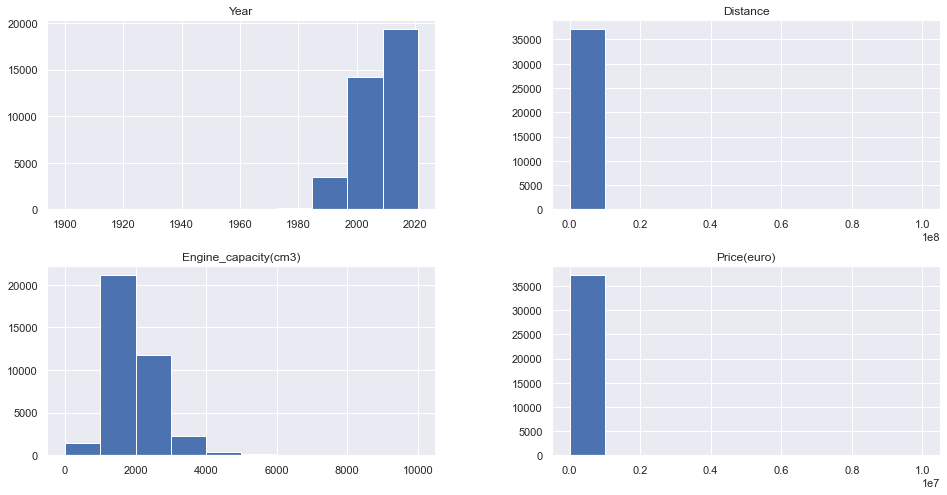

In [9]:
width = 2
fig, ax = plt.subplots(nrows=int(np.ceil(len(num_columns)/width)), ncols=width, figsize=(16,8))

for idx, column_name in enumerate(num_columns):
    col_idx = idx//width
    row_idx = idx%width
    df.hist(column = [column_name], ax=ax[col_idx,row_idx]);

Столбцы имеют явные аномалии, особенно Distance и Price(euro). Чтобы лучше понять эти аномалии посмотрим на столбцы в логарифмическом масштабе.

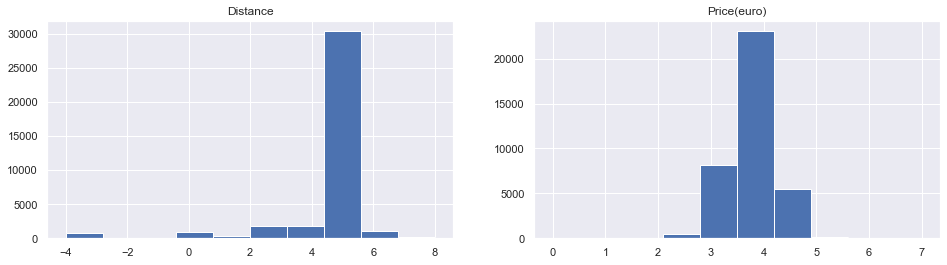

In [10]:
plt.figure(figsize=(16,4))
plt.subplot(121);plt.hist(np.log10(np.abs(df.Distance)+0.0001));plt.title('Distance')
plt.subplot(122);plt.hist(np.log10(np.abs(df['Price(euro)'])+0.0001));plt.title('Price(euro)')
plt.show()

Теперь мы можем определить, что нам требуется, чтобы почистить столбцы. Также, так как задача хорошо интерпретируема мы можем почистить столбцы пользуясь здравым смыслом. Например, мы можем удалить записи, где цена меньше 100 евро или пробег меньше 1000 км и год старый.

In [11]:
# due to reasonableness
question_dist = df[(df.Year <2021) & (df.Distance < 1100)]
df = df.drop(question_dist.index)

#histogram analysis
question_dist = df[(df.Distance > 1e6)]
df = df.drop(question_dist.index)

# due to reasonableness
question_engine = df[df["Engine_capacity(cm3)"] < 200]
df = df.drop(question_engine.index)

# due to reasonableness
question_engine = df[df["Engine_capacity(cm3)"] > 5000]
df = df.drop(question_engine.index)

# due to reasonableness
question_price = df[df["Price(euro)"] < 101]
df = df.drop(question_price.index)

# due to reasonableness
question_price = df[df["Price(euro)"] > 1e5]
df = df.drop(question_price.index)

#histogram analysis
question_year = df[df.Year < 1971]
df = df.drop(question_year.index)

df = df.reset_index(drop=True)
df.tail()

,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Price(euro)
32601,Volkswagen,Passat,2016,Sedan,88000.0,1800.0,Petrol,Automatic,11500.0
32602,Land Rover,Freelander,2002,Crossover,225000.0,1800.0,Metan/Propan,Manual,4400.0
32603,Dacia,Logan Mcv,2015,Universal,89000.0,1500.0,Diesel,Manual,7000.0
32604,Mazda,6,2006,Combi,370000.0,2000.0,Diesel,Manual,4000.0
32605,Renault,Grand Scenic,2006,Minivan,300000.0,1500.0,Diesel,Manual,4000.0


Посмотрим на результат

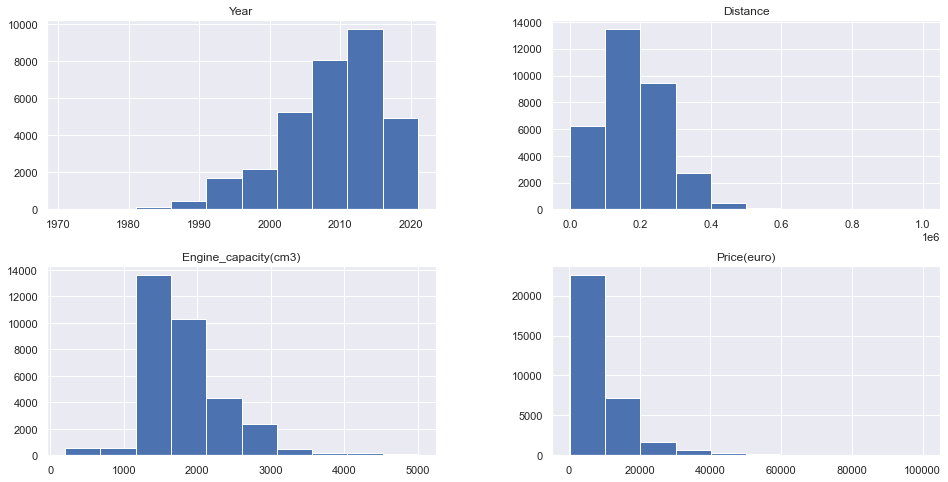

In [12]:
width = 2
fig, ax = plt.subplots(nrows=int(np.ceil(len(num_columns)/width)), ncols=width, figsize=(16,8))

for idx, column_name in enumerate(num_columns):
    col_idx = idx//width
    row_idx = idx%width
    
    df.hist(column = [column_name], ax=ax[col_idx,row_idx]);

### Вопрос:

<b>Начиная с кокого года мы теперь анализируем автомобили?<br>


### Вопрос:

<b>Назовите максимальную цену автомобиля?<br>


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32606 entries, 0 to 32605
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Make                  32606 non-null  object 
 1   Model                 32606 non-null  object 
 2   Year                  32606 non-null  int64  
 3   Style                 32606 non-null  object 
 4   Distance              32606 non-null  float64
 5   Engine_capacity(cm3)  32606 non-null  float64
 6   Fuel_type             32606 non-null  object 
 7   Transmission          32606 non-null  object 
 8   Price(euro)           32606 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 2.2+ MB


Text(0.5, 1.0, 'Distance-Price')

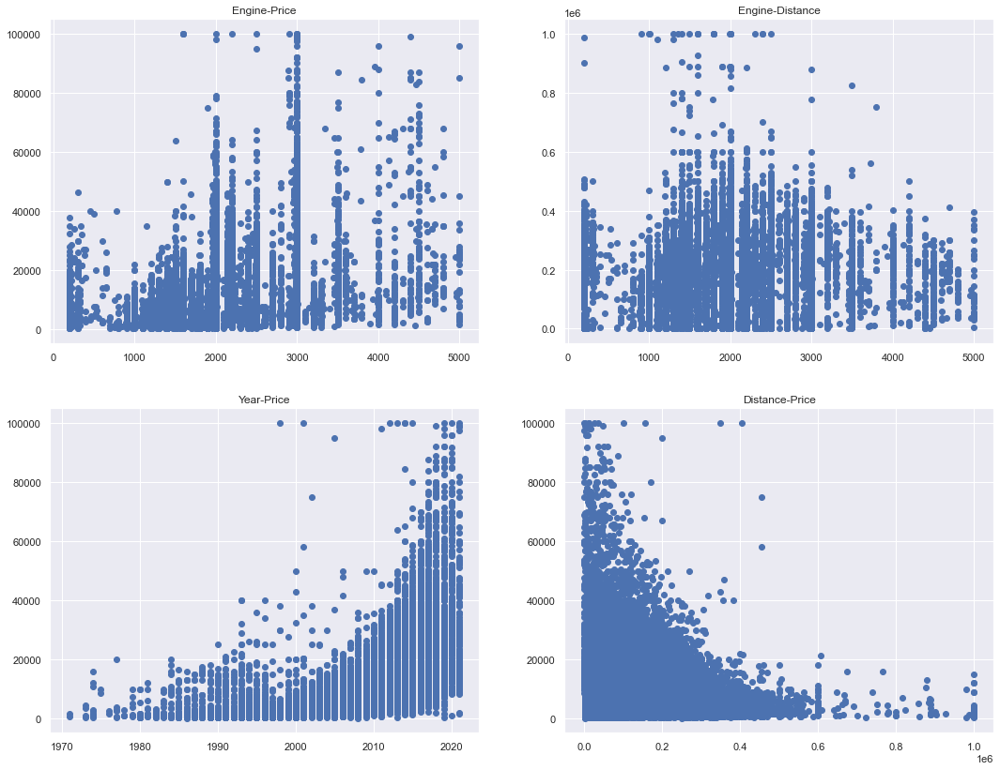

In [14]:
plt.figure(figsize=(18,14))
plt.subplot(221)
plt.scatter(df["Engine_capacity(cm3)"], df["Price(euro)"]); plt.title("Engine-Price")
plt.subplot(222)
plt.scatter(df["Engine_capacity(cm3)"], df["Distance"]);   plt.title("Engine-Distance") 
plt.subplot(223)
plt.scatter(df["Year"], df["Price(euro)"]);   plt.title("Year-Price") 
plt.subplot(224)
plt.scatter(df["Distance"], df["Price(euro)"]);   plt.title("Distance-Price")  
# plt.subplot(324)
# plt.scatter(df["Year"], df["Distance"]);   plt.title("Year-Distance") 
# plt.subplot(325)
# plt.scatter(df["Year"], df["Engine_capacity(cm3)"]);   plt.title("Year-Engine")  

### Добавление колонки
Зная суть или модель данных мы можем предположить, чего нам не хватает - то есть попробовать добавить новый признак в данные. Такую операцию можно провести по-разному. В данном случае мы сделаем это исходя из логики. Введем признак пробег в год. \
Отметим, что важно, чтобы новый признак был независим от других - иначе его потом придется удалить.


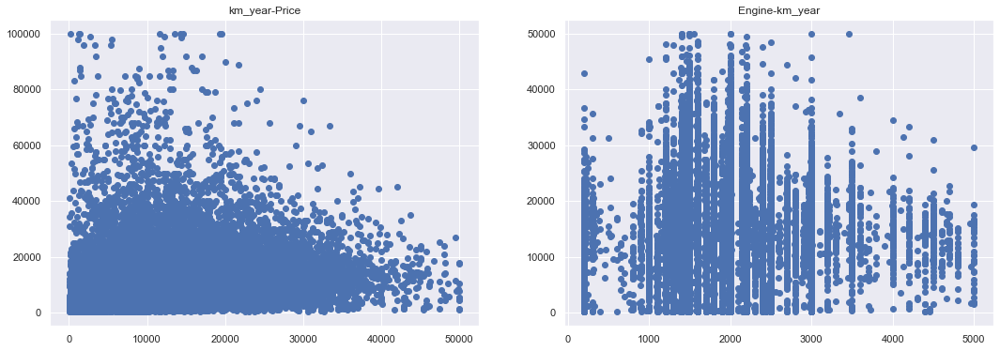

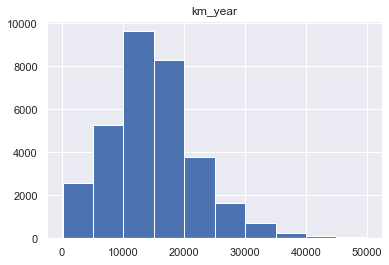

In [15]:
df['km_year'] = df.Distance / (2022 - df.Year)
question_km_year = df[df.km_year > 50e3]
df = df.drop(question_km_year.index)
question_km_year = df[df.km_year < 100]
df = df.drop(question_km_year.index)
df = df.reset_index(drop=True)

plt.figure(figsize=(18,6))
plt.subplot(121); plt.scatter(df["km_year"], df["Price(euro)"]); plt.title("km_year-Price")
plt.subplot(122); plt.scatter(df["Engine_capacity(cm3)"], df["km_year"]); plt.title("Engine-km_year")
plt.show();

df.hist(column = ["km_year"]);

### Вопрос:

<b>Назовите величину максимального пробега в год с точностью до целых числен<br>


### Удаление аномалий и связанных признаков.
Часто проведенного выше анализа данных бывает недостаточно. Помимо всего выше изложенного бывает необходимо удаление аномалий из данных.

Посмотрим на аномалии с использованием т.н. boxplot - метода. Метод фактически визуализирует распределение для каждой категории, где основной прямоугольник - это основной диапазон значений, его центр (Обозначен линией) это центральная мода - то есть максимум, основные усы - это ожидаемый разброс, а все что за ними - это аномалии.

![](https://static.tildacdn.com/tild6533-3362-4632-b632-333165363837/image.png) 

<AxesSubplot:>

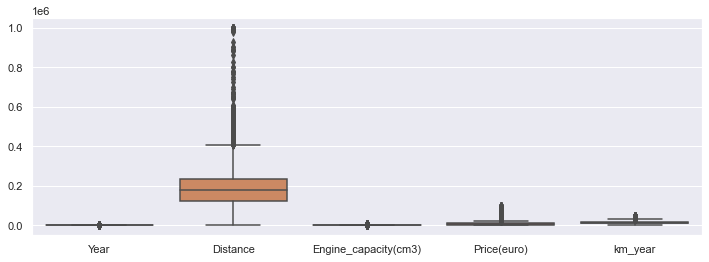

In [16]:
fig = plt.figure(figsize=(12,4))
sns.boxplot(data =df)

### Вопрос:

<b>Какой столбец заслуживает фильтрации на аномалии больше всего <br>


<AxesSubplot:>

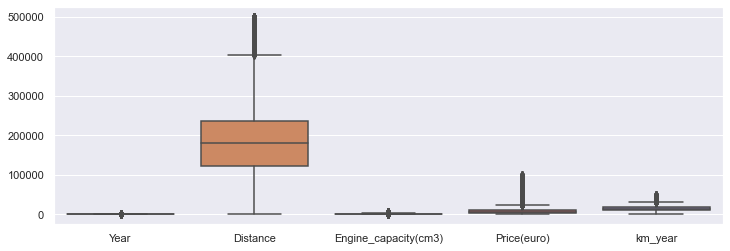

In [17]:
question_dist = df[(df.Distance > 0.5e6)]
df = df.drop(question_dist.index)

df = df.reset_index(drop=True)

fig = plt.figure(figsize=(12,4))
sns.boxplot(data =df)

Посмотрим на корреляцию численных столбцов. Корреляция - это степень линейной зависимости между двумя наборами данных. Например, если два вектора коллиниарны, то их корреляция = 1, если анти коллиниарны, то -1. Если два вектора ортогональны, то корреляция = 0. Для СЛАУ коррелированность значит вырожденность, то есть если есть СЛАУ с двумя выжражениями коррелирующими (+-1) друг с другом, то СЛАУ вырождена. Чем меньше корреляция - тем менее вырождена (лучше обусловлена) СЛАУ. Если в слау выражений больше чем искомых переменных, то есть, есть запас - то несколько коллиниарностей не приведут к вырожденности, но скажутся на времени вычислений, и вряд ли повысят точность. То есть мы хотим найти, если есть, коллиниарные колонки в наборе и их удалить.

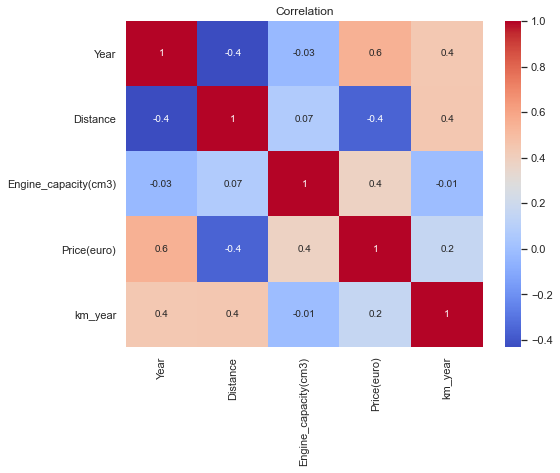

In [18]:
fig, ax = plt.subplots(figsize=(8,6))
plt.title('Correlation')
sns.heatmap(df.corr(), annot=True, fmt='.1g', cmap="coolwarm");

### Вопрос:

<b>Назовите параметр наименее коррелирующий с целевым показателем<br>


### Вопрос:

<b>Назовите пару показателей с наибольшей корреляцией<br>


### Вопрос:

<b>Назовите корреляцию между <code> km_year  и year и distance<br>


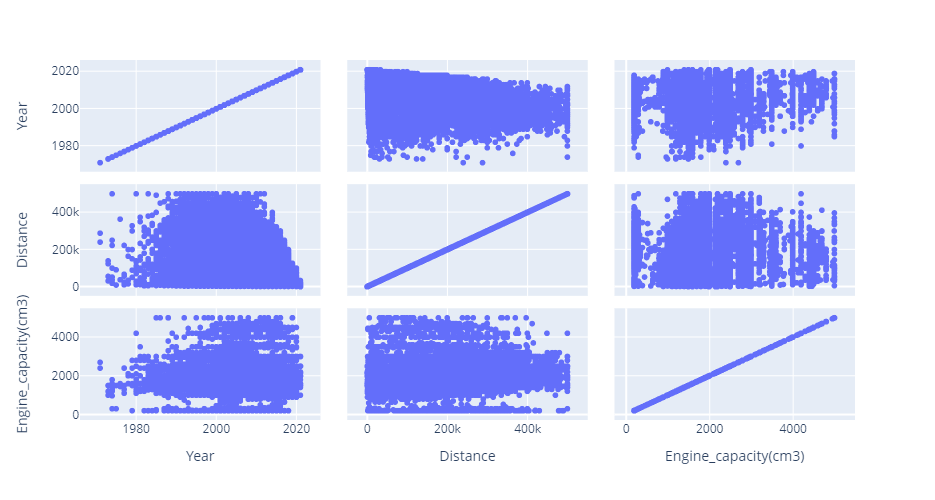

In [19]:
fig = px.scatter_matrix(df[num_columns[:-1]], 
                        width=500, 
                        height=500)
fig.show()

### Категориальные данные
посмотрим на число повторений результата в каждом категориальном признаке. Очевидно, следует ожидать, что для категориального признака самым важным становится число повторений каждого значения. Если такое число мало - скорее всего данное значение не информативно. 

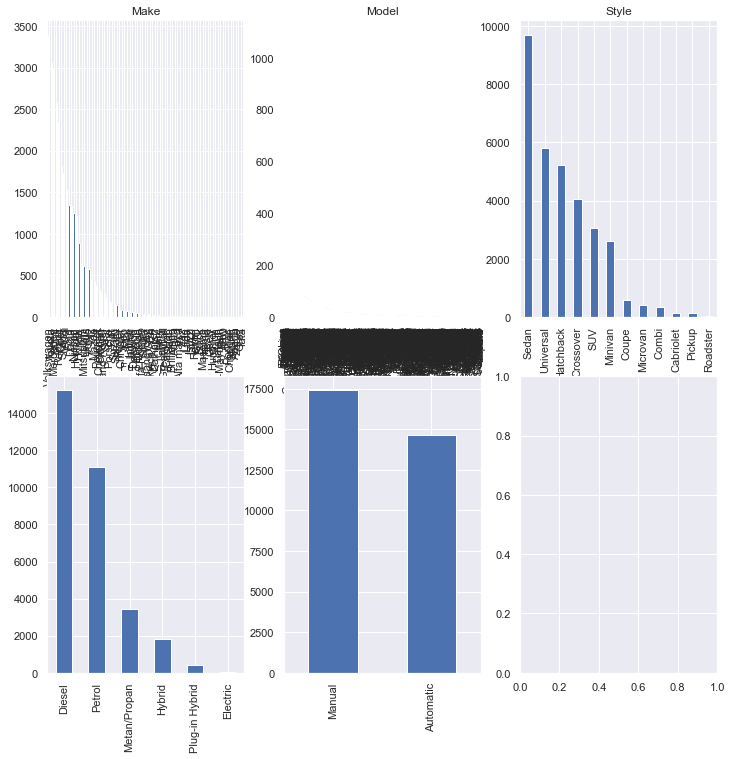

In [20]:
fig, ax = plt.subplots(nrows=int(np.ceil(len(cat_columns)/3)), ncols=3, figsize=(12,12))

for idx, column_name in enumerate(cat_columns):
    col_idx = idx//3
    row_idx = int(idx%3)
    df[column_name].value_counts().plot(ax = ax[col_idx,row_idx], kind='bar',title=column_name)


### Вопрос: 

<b>Назовите бирнарный признак (то есть тот, по которму можно сделать замену вида "да-нет"
   

### Вопрос: 

<b>Назовите какие столбцы следует фильтровать больше всего (два)
    

Давайте также проверим как распределены данные в зависимости от типа трансмиссии 

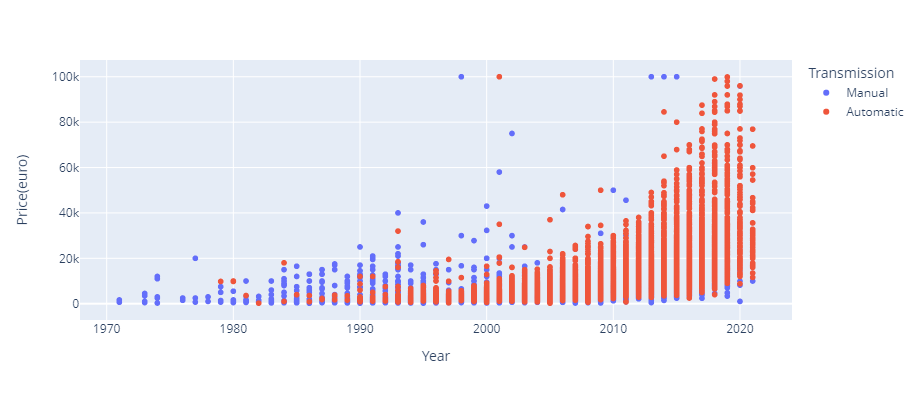

In [21]:
px.scatter(df.sample(20000),
          x = "Year",
          y = "Price(euro)",
          color = "Transmission",
          width=600, height=400)

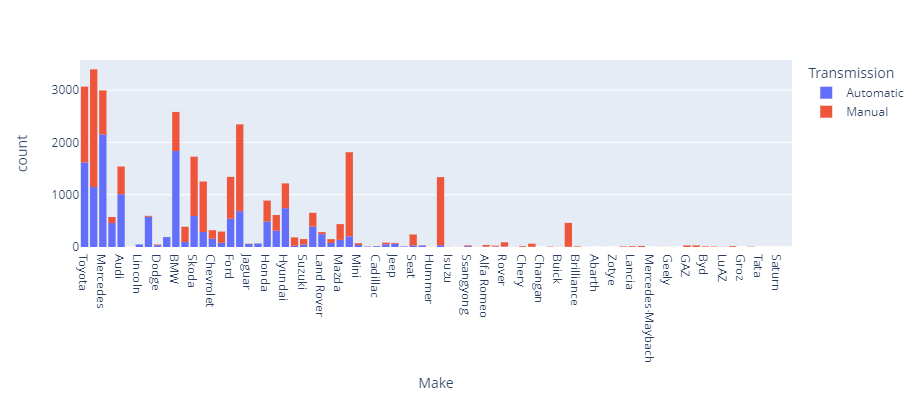

In [22]:
px.histogram(df,x='Make', color='Transmission', width=600, height=400)

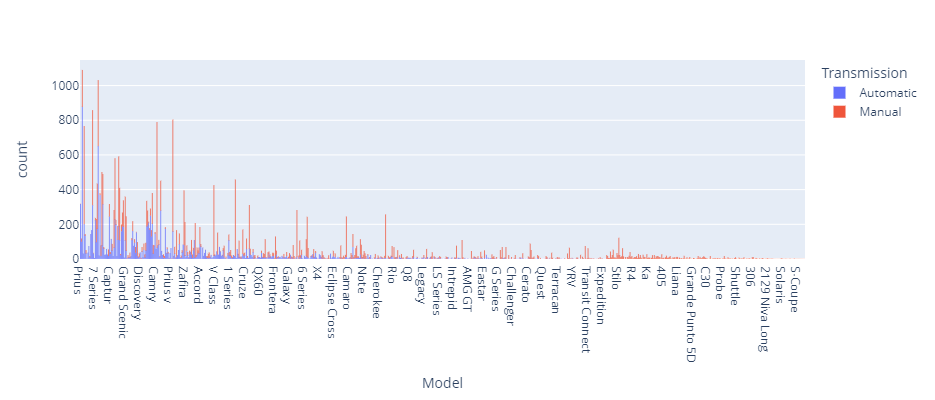

In [23]:
px.histogram(df,x='Model', color='Transmission', width=600, height=400)

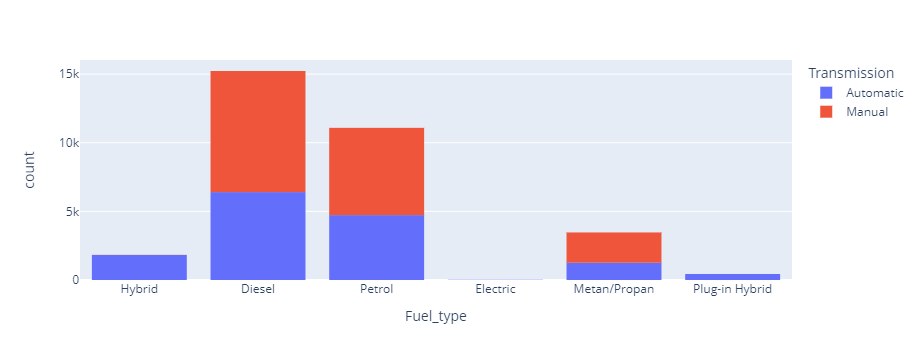

In [24]:
px.histogram(df, x='Fuel_type',color='Transmission' ,width=600, height=300 )

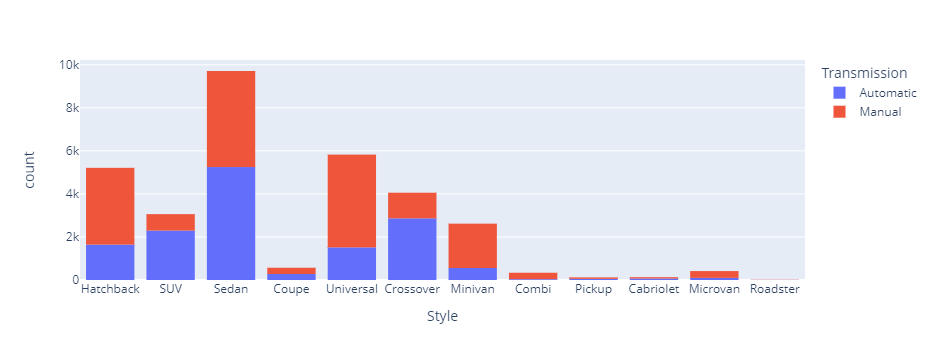

In [25]:
px.histogram(df, x='Style',color='Transmission' ,width=600, height=300 )

Оказалось, что часть из наших признаков имеют слишком много записей.<br>
Вероятно, редкие значения можно исключить без потери точности.<br>
Мы сделаем эту операцию объявив такие записи одним типом - rare.<br>
Такая операция характерна именно для категориальных данных  - новый тип будет информативен, так как его представителей будет много. Однако, если бы тип rare стал слишьком превалировать над остальными, то следовало бы подумать о других заменах.

In [26]:
counts = df.Make.value_counts()
counts

Volkswagen    3396
Toyota        3066
Mercedes      2993
BMW           2582
Renault       2344
              ... 
Saturn           1
Abarth           1
Zotye            1
Groz             1
Tata             1
Name: Make, Length: 78, dtype: int64

In [27]:
rare =  counts[(counts.values < 10)]
df['Make'] = df['Make'].replace(rare.index.values, 'Rare')
df.Make.value_counts()

Volkswagen        3396
Toyota            3066
Mercedes          2993
BMW               2582
Renault           2344
Opel              1812
Skoda             1726
Audi              1538
Ford              1341
Dacia             1336
Nissan            1252
Hyundai           1216
Honda              887
KIA                654
Mitsubishi         611
Lexus              595
Volvo              574
Vaz                461
Mazda              437
Peugeot            387
Chevrolet          321
Citroen            295
Land Rover         285
Seat               239
Porsche            190
Fiat               183
Suzuki             152
Subaru             150
Rover               90
Chrysler            83
Jeep                77
Mini                72
Rare                70
Infiniti            67
Jaguar              64
Daewoo              63
Lincoln             49
Dodge               49
Alfa Romeo          38
Smart               33
Ssangyong           32
GAZ                 30
Moskvich / Izh      29
Daihatsu   

In [28]:
counts = df.Model.value_counts()
rare =  counts[(counts.values < 50)]
df['Model'] = df['Model'].replace(rare.index.values, 'Rare')
df.Model.value_counts()

Rare             6680
E Class          1090
5 Series         1030
Passat            858
Megane            803
                 ... 
Vento              51
Urban Cruiser      51
Accent             51
Matrix             50
Avensis Verso      50
Name: Model, Length: 134, dtype: int64

### Вопрос: 

<b>Назовите самую распростроненную марку (кроме Rare)
    

### Вопрос: 

<b>Назовите самую распростроненную модель (кроме Rare)
   

## Приведение категориальных признаков к численным

### Бинарные признаки

In [29]:
df['Transmission'] = df['Transmission'].map({'Automatic': 1, 'Manual': 0})

### Пространственное кодирование многозначных признаков
Пространственным (sparce) - называется кодирование, когда мы назначем какую либо цифру каждому признаку, например, 1 - lada, 2 - skoda, 3 - honda и т.д. Такое кодирование очевидно и пригодно для некоторых алгоритмов машинного обучения (почти для всех популярных алгоритмов). Однако, в ряде случаев такое кодирование нельзя использовать, например, если код будет означеть какой-либо приоретет, например honda над lada. Такая ситуация (приоретет) характерна для линейных алгоритмов, например линейной или логистической регрессии. Для них мы предусмотрим другое кодирование.

In [30]:
df_se = df.copy()
df_se[cat_columns] = df_se[cat_columns].astype('category')

for _, column_name in enumerate(cat_columns):
    df_se[column_name] =  df_se[column_name].cat.codes
df_se.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32074 entries, 0 to 32073
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Make                  32074 non-null  int8   
 1   Model                 32074 non-null  int16  
 2   Year                  32074 non-null  int64  
 3   Style                 32074 non-null  int8   
 4   Distance              32074 non-null  float64
 5   Engine_capacity(cm3)  32074 non-null  float64
 6   Fuel_type             32074 non-null  int8   
 7   Transmission          32074 non-null  int8   
 8   Price(euro)           32074 non-null  float64
 9   km_year               32074 non-null  float64
dtypes: float64(4), int16(1), int64(1), int8(4)
memory usage: 1.4 MB


Посмотрим какой теперь стала наша матрица взаимных корреляций

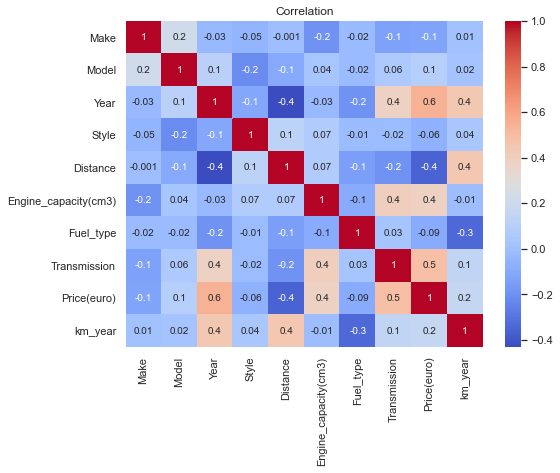

In [31]:
fig, ax = plt.subplots(figsize=(8,6))
plt.title('Correlation')
sns.heatmap(df_se.corr(), annot=True, fmt='.1g', cmap="coolwarm");

### Вопрос: 
<b>Назовите столбец наименее коррелриующий с Transmission? 
   

### Вопрос: 
<b>Назовите столбец более всего зависящий от Transmission? 
    

### One-hot кодирование многозначных признаков
Данный тип кодирование - это альтернатива простарнственному кодированию. Тип подходит для линейных алгоритмов. Также данный тип может быть использован в более сложных подходах к анализу данных, выходящих за рамки курса (например, мягкие метки).

Принцип данного кодирования заключается в том, что мы заменяем один категориальный столбец на несколько таких, что каждый будет соответствовать одной категории, а его значения будут или 0 или 1 - если для записи (строчки) имеет место такая категория.

![](https://russianblogs.com/images/855/ddd65f4f342886bb411d41a33c5528e7.png)


In [32]:
df_ohe = df.copy()
df_ohe = pd.get_dummies(df_ohe)
df_ohe.tail()

,Year,Distance,Engine_capacity(cm3),Transmission,Price(euro),km_year,Make_Acura,Make_Alfa Romeo,Make_Alta marca,Make_Audi,...,Style_Roadster,Style_SUV,Style_Sedan,Style_Universal,Fuel_type_Diesel,Fuel_type_Electric,Fuel_type_Hybrid,Fuel_type_Metan/Propan,Fuel_type_Petrol,Fuel_type_Plug-in Hybrid
32069,2016,88000.0,1800.0,1,11500.0,14666.666667,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
32070,2002,225000.0,1800.0,0,4400.0,11250.000000,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
32071,2015,89000.0,1500.0,0,7000.0,12714.285714,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
32072,2006,370000.0,2000.0,0,4000.0,23125.000000,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
32073,2006,300000.0,1500.0,0,4000.0,18750.000000,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [33]:
df_ohe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32074 entries, 0 to 32073
Columns: 214 entries, Year to Fuel_type_Plug-in Hybrid
dtypes: float64(4), int64(2), uint8(208)
memory usage: 7.8 MB


### Вопрос: 
<b>Сколько столбцов получилось ? 
    

In [34]:
df_ohe.describe()

,Year,Distance,Engine_capacity(cm3),Transmission,Price(euro),km_year,Make_Acura,Make_Alfa Romeo,Make_Alta marca,Make_Audi,...,Style_Roadster,Style_SUV,Style_Sedan,Style_Universal,Fuel_type_Diesel,Fuel_type_Electric,Fuel_type_Hybrid,Fuel_type_Metan/Propan,Fuel_type_Petrol,Fuel_type_Plug-in Hybrid
count,32074.000000,32074.000000,32074.000000,32074.000000,32074.000000,32074.000000,32074.000000,32074.000000,32074.000000,32074.000000,...,32074.000000,32074.000000,32074.000000,32074.000000,32074.000000,32074.000000,32074.000000,32074.000000,32074.000000,32074.000000
mean,2008.336004,180297.720646,1868.531770,0.457660,9479.187722,14882.489475,0.000436,0.001185,0.000405,0.047952,...,0.000686,0.095373,0.302706,0.181611,0.474652,0.000904,0.057243,0.107969,0.345576,0.013656
std,7.162778,90541.530459,609.824918,0.498212,9531.545838,7251.805242,0.020888,0.034400,0.020129,0.213667,...,0.026181,0.293734,0.459436,0.385530,0.499365,0.030056,0.232309,0.310346,0.475563,0.116060
min,1971.000000,100.000000,200.000000,0.000000,200.000000,100.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2005.000000,123000.000000,1500.000000,0.000000,3600.000000,10250.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2010.000000,180000.000000,1800.000000,0.000000,6799.000000,14432.509804,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2014.000000,235359.250000,2000.000000,1.000000,12075.250000,18800.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,2021.000000,500000.000000,5000.000000,1.000000,100000.000000,50000.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Вопрос: 
<b>Назовите средний год по выборке? 
    

Сохраним полученные данные в нескольких видах, которые понадобяться нам позже. 

In [35]:
df_num = df[num_columns].copy()
df_num.to_csv('car_num.csv')

df_cat = df[cat_columns].copy()
df_cat.to_csv('car_cat.csv')

df_se.to_csv('car_se.csv')

df_ohe.to_csv('car_ohe.csv')


проверим, что все открылось как следует


In [36]:
df_se = pd.read_csv("car_se.csv")
df_se

,Unnamed: 0,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Price(euro),km_year
0,0,50,92,2011,4,195000.0,1800.0,2,1,7750.0,17727.272727
1,1,41,62,2014,11,135000.0,1500.0,0,0,8550.0,16875.000000
2,2,41,71,2012,11,110000.0,1500.0,0,0,6550.0,11000.000000
3,3,37,23,2006,11,200000.0,1600.0,3,0,4100.0,12500.000000
4,4,32,124,2000,5,300000.0,2200.0,0,0,3490.0,13636.363636
...,...,...,...,...,...,...,...,...,...,...,...
32069,32069,53,88,2016,10,88000.0,1800.0,4,1,11500.0,14666.666667
32070,32070,27,53,2002,3,225000.0,1800.0,3,0,4400.0,11250.000000
32071,32071,12,77,2015,11,89000.0,1500.0,0,0,7000.0,12714.285714
32072,32072,31,10,2006,1,370000.0,2000.0,0,0,4000.0,23125.000000
